# Validation — enriched vs random TF force

In [ ]:
# Dataset locations for this notebook come from ../datasets.yaml.
# Edit that file to point at your own copies -- do not hardcode paths below.
from firefate.io import DatasetPaths

config = DatasetPaths.from_yaml("../datasets.yaml")


In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [2]:
import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *

In [ ]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import state_dynamics
# re-bind
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(state_dynamics)
from state_dynamics import TFForceWaves, StateFrequency, BindingPhases
from dynamic_validation import TFForceValidation

In [5]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(config.DYNAMIC_H5)

### Defining lineage trajectories

In [6]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [7]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

### Loading prioritized tfs

In [8]:
ss_firefate_combined = pd.read_csv(config.SS_LINKS_CSV)

In [9]:
display(ss_firefate_combined)

,source,target,key,weight,cluster,strength,case
0,PRDM1,RUNX2,1,0.293075,3,1,slide
1,PRDM1,IQGAP2,1,0.219831,3,1,slide
2,BACH2,XBP1,0,-0.229950,7,1,slide
3,BACH2,MZB1,1,-0.234813,3,1,slide
4,BACH2,JCHAIN,1,-0.258168,3,1,slide
...,...,...,...,...,...,...,...
73,PBX3,CDK6,1,0.231756,3,1,slide
74,PBX3,AFF3,1,0.332018,3,1,slide
75,ARID5B,CPEB4,1,0.237878,3,1,slide
76,ARID5B,PDE4D,0,0.228636,7,1,slide


In [10]:
# Build (TF, target) tuples, keeping only links whose TF and target are both
# present in the dictys object. get_beta_curves can only compute forces for genes
# in the GRN (TFs in nids[0], targets in ndict); filtering here makes the computed
# link set explicit rather than relying on the internal skip.
all_links = list(zip(ss_firefate_combined['source'], ss_firefate_combined['target']))

_, _, missing_tfs = get_tf_indices(dictys_dynamic_object, list({tf for tf, _ in all_links}))
missing_tfs = set(missing_tfs)
ndict = dictys_dynamic_object.ndict

ss_firefate_combined_tuple = [(tf, tg) for tf, tg in all_links
                     if tf not in missing_tfs and tg in ndict]
dropped = [(tf, tg) for tf, tg in all_links
           if tf in missing_tfs or tg not in ndict]
print(f"{len(ss_firefate_combined_tuple)}/{len(all_links)} links kept; "
      f"{len(dropped)} dropped (TF/target absent from GRN): {dropped}")

66/78 links kept; 12 dropped (TF/target absent from GRN): [('AFF1', 'MAN1A1'), ('AFF1', 'FNDC3A'), ('AFF1', 'CEP128'), ('HERPUD1', 'TRAM1'), ('HERPUD1', 'IRF4'), ('HERPUD1', 'BTG2'), ('HERPUD1', 'PAX5'), ('HIVEP2', 'IRF4'), ('HIVEP2', 'BTG2'), ('HIVEP2', 'GAB1'), ('HIVEP2', 'GLCCI1'), ('HIVEP2', 'CPEB4')]


In [11]:
# load the episodically enriched links from file
episodic_links_file = config.EPISODIC_LINKS_CSV
episodic_links = pd.read_csv(episodic_links_file)

In [12]:
display(episodic_links)

,lineage,episode,TF,p_value,genes_in_lf,n_genes_in_lf
0,GC,Ep4,CDC5L,0.003546,"ARNTL2, MZB1, TNFAIP8, UBAC2",4
1,GC,Ep1,CREB3L2,0.009150,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1, TXNDC5",6
2,GC,Ep1,IKZF3,0.002195,"ANKRD28, CD74, PIKFYVE, RNF213",4
3,GC,Ep3,IRF7,0.005185,"B2M, CEP128",2
4,GC,Ep4,IRF7,0.001808,"B2M, CEP128",2
5,GC,Ep4,MEF2C,0.000220,"IRF4, SEL1L3, SLA, TNFAIP8",4
6,GC,Ep4,POU2F1,0.006940,"CCSER2, DEK, EEA1, IRF4, MAPK1, SLC25A13",6
7,GC,Ep3,USF2,0.001520,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
8,GC,Ep4,USF2,0.004210,"FNDC3A, HSP90B1, LMAN1, RNF213, SSR1, SUB1, TRAM1",7
9,PB,Ep1,CREB3L2,0.000220,"FNDC3A, HSP90B1, LMAN1, SSR1, TRAM1",5


In [13]:
#create tuples from the TF and genes_in_lf list of comma separated targets and take union of all links across all rows to make a unique set of links
episodic_links_tuples = set()
for _, row in episodic_links.iterrows():
    tf = row['TF']
    targets = row['genes_in_lf'].split(',')
    for target in targets:
        episodic_links_tuples.add((tf, target.strip()))


In [14]:
display(len(episodic_links_tuples))

55

# TF forces

In [ ]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [ ]:
# GC branch: same TF-forces machinery over the GC trajectory (node 0 -> 3).
waves_gc = TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

### Cross-branch pooled comparison (PB ∪ GC)

In [ ]:
# Combined 3-box comparison: state-specific enriched, episodic enriched, and ONE shared
# random null (size-matched to the larger of the two enriched sets; drawn with every
# TF/target from BOTH sets removed). Each link scored by abs-max TF force across PB & GC.
combo_df = TFForceValidation.compare_sets(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(combo_df['group'].value_counts())

fig, ax = TFForceValidation.plot_multi(
    combo_df,
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific\nenriched', 'Episodic\nenriched', 'Random\n(non-enriched)'],
    ylabel='abs(max TF-force)',
)
# fig.savefig(f"{config.OUTPUT_FOLDER}/combined_links_validation.svg",
#             format='svg', bbox_inches='tight')
plt.show()

## Phase definitions

In [15]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
sf_pb = StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
pseudotime_values_of_windows_pb = sf_pb.pseudotime_values_of_windows

In [16]:
# Class 1: cell-state fate frequencies + extrema / termination pseudotimes
sf_gc = StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 3),
)
pseudotime_values_of_windows_gc = sf_gc.pseudotime_values_of_windows

In [17]:
# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

### TF Force Phase split validation

In [ ]:
import importlib, dynamic_validation
importlib.reload(dynamic_validation)
from dynamic_validation import TFForceValidation

# PB switch boundaries = termination pseudotimes of ActB-4 then earlyPB (3 phases).
pb_switches = [sf_pb.termination_pseudotime(s, PB_post_bifurcation_window_indices,
                                            method='threshold')
               for s in ['ActB-4', 'earlyPB']]

# Classify the universe of enriched links (state-specific + episodic) into PB phases,
# keeping only links whose winning branch is PB, then compare the two enriched sets
# against ONE shared per-phase random null. Each point is a link's abs-max TF force,
# which (since phase = where the force peaks) is its in-phase peak force.
pb_phase_df = TFForceValidation.compare_sets_by_phase(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'PB': pb_switches},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(pb_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))

In [ ]:
# GC switch boundary = termination pseudotime of ActB-3 (2 phases).
gc_switches = [sf_gc.termination_pseudotime('ActB-3', GC_post_bifurcation_window_indices,
                                            method='threshold')]

# Classify the universe of enriched links (state-specific + episodic) into GC phases,
# keeping only links whose winning branch is GC, then compare the two enriched sets
# against ONE shared per-phase random null. Each point is a link's abs-max TF force,
# which (since phase = where the force peaks) is its in-phase peak force.
gc_phase_df = TFForceValidation.compare_sets_by_phase(
    {'PB': waves_pb, 'GC': waves_gc},
    {'State-specific': ss_firefate_combined_tuple,
     'Episodic': episodic_links_tuples},
    switch_pseudotimes={'GC': gc_switches},
    varname='w_in', exclude='tf_and_target', random_state=0,
)
display(gc_phase_df.groupby(['phase', 'group']).size().unstack(fill_value=0))

In [ ]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    pb_phase_df, branch='PB',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    xlabel= ['Phase 1', 'Phase 2', 'Phase 3']
)
ax.set_title('PB phases')
fig.savefig(f"{config.OUTPUT_FOLDER}/pb_phase_links_validation.svg",
            format='svg', bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = TFForceValidation.plot_multi_by_phase(
    gc_phase_df, branch='GC',
    group_order=['State-specific', 'Episodic', 'random'],
    group_labels=['State-specific', 'Episodic', 'Random (non-enriched)'],
    ylabel='Abs max TF force (in-phase)',
    xlabel=['Phase 1', 'Phase 2'],
)
ax.set_title('GC phases')
fig.savefig(f"{config.OUTPUT_FOLDER}/gc_phase_links_validation.svg",
            format='svg', bbox_inches='tight')
plt.show()

# TF Binding Dynamics

In [18]:
base_path = config.TMP_DYNAMIC
from firefate.core.pseudotime_curves import SmoothedCurvesChromatin

smooth_chromatin_object = SmoothedCurvesChromatin(
    tfs=None,
    base_path=base_path
)

In [19]:
aligner_pb = AlignTimeScales(dictys_dynamic_object, trajectory_range=(0, 2),
                             num_points=40, dist=0.001, sparsity=0.01)
aligner_gc = AlignTimeScales(dictys_dynamic_object, trajectory_range=(0, 3),
                             num_points=40, dist=0.001, sparsity=0.01)

window_pseudotimes_pb = aligner_pb.pseudotime_of_windows()
window_pseudotimes_gc = aligner_gc.pseudotime_of_windows()

smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes_pb,        # PB frame (0,2)
    gc_window_pseudotimes=window_pseudotimes_gc,     # GC frame (0,3)
)

In [20]:
smooth_chromatin_object.set_trajectory_info(
    pb_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2],
    gc_indices=[1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3],
    window_pseudotimes=window_pseudotimes_pb,        # PB frame (0,2)
    gc_window_pseudotimes=window_pseudotimes_gc,     # GC frame (0,3)
)
smooth_chromatin_object.extract_data(n_windows=194, n_processes=None)
smooth_chromatin_object.process_dynamics()

Processing 194 windows using 127 processes...


Extracting Binding Data: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 194/194 [00:26<00:00,  7.26it/s]


Discovered 551 TFs across all windows.
Extraction complete.


In [40]:
import importlib, state_dynamics
importlib.reload(state_dynamics)
from state_dynamics import BindingPhases

bp_pb = BindingPhases(pb_switches, smooth_chromatin_object, 'pb',
                      window_indices=PB_post_bifurcation_window_indices)
bp_gc = BindingPhases(gc_switches, smooth_chromatin_object, 'gc',
                      window_indices=GC_post_bifurcation_window_indices)

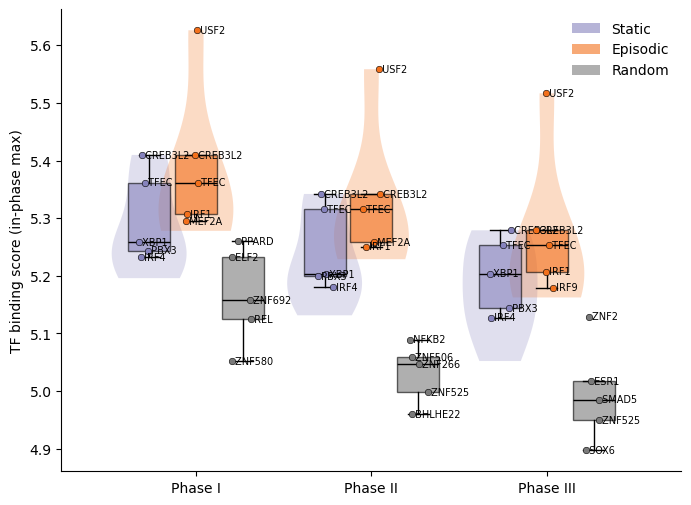

In [45]:
SEED = 0
fig, ax = bp_pb.plot_box(category_tfs, top_k=5, annotate=True, violin=True,
                         random_control=True, random_state=SEED)
fig.savefig(f"{config.OUTPUT_FOLDER}/pb_tf_binding_in_phase.svg",
            format='svg', bbox_inches='tight')
plt.show()

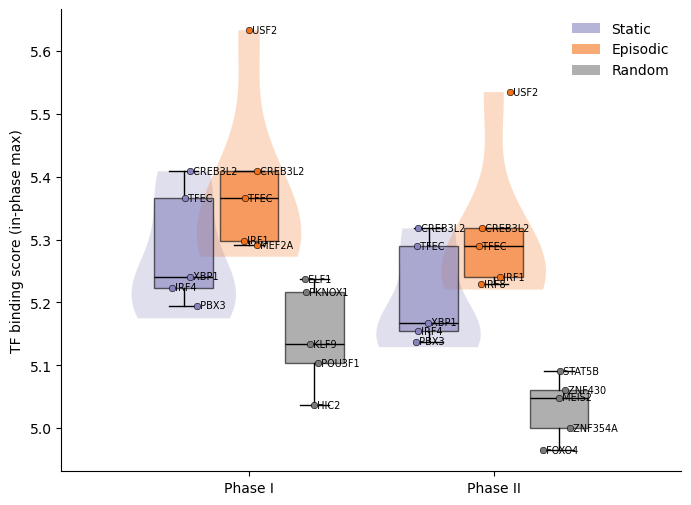

In [46]:
fig, ax = bp_gc.plot_box(category_tfs, top_k=5, annotate=True, violin=True,
                         random_control=True, random_state=SEED)
fig.savefig(f"{config.OUTPUT_FOLDER}/gc_tf_binding_in_phase.svg",
            format='svg', bbox_inches='tight')